In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/datathon-2026-round-1/products.csv
/kaggle/input/competitions/datathon-2026-round-1/sample_submission.csv
/kaggle/input/competitions/datathon-2026-round-1/promotions.csv
/kaggle/input/competitions/datathon-2026-round-1/shipments.csv
/kaggle/input/competitions/datathon-2026-round-1/order_items.csv
/kaggle/input/competitions/datathon-2026-round-1/reviews.csv
/kaggle/input/competitions/datathon-2026-round-1/inventory.csv
/kaggle/input/competitions/datathon-2026-round-1/returns.csv
/kaggle/input/competitions/datathon-2026-round-1/sales.csv
/kaggle/input/competitions/datathon-2026-round-1/orders.csv
/kaggle/input/competitions/datathon-2026-round-1/geography.csv
/kaggle/input/competitions/datathon-2026-round-1/customers.csv
/kaggle/input/competitions/datathon-2026-round-1/baseline.ipynb
/kaggle/input/competitions/datathon-2026-round-1/payments.csv
/kaggle/input/competitions/datathon-2026-round-1/web_traffic.csv


In [37]:
# Cài đặt thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATA_PATH = '/kaggle/input/competitions/datathon-2026-round-1/'
print('Imports OK')

Imports OK


In [38]:
# ── 1. Load toàn bộ dữ liệu ────────────────────────────────────────────────
orders      = pd.read_csv(f'{DATA_PATH}orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_PATH}order_items.csv', low_memory=False)
products    = pd.read_csv(f'{DATA_PATH}products.csv')
customers   = pd.read_csv(f'{DATA_PATH}customers.csv', parse_dates=['signup_date'])
geography   = pd.read_csv(f'{DATA_PATH}geography.csv')
payments    = pd.read_csv(f'{DATA_PATH}payments.csv')
returns     = pd.read_csv(f'{DATA_PATH}returns.csv', parse_dates=['return_date'])
reviews     = pd.read_csv(f'{DATA_PATH}reviews.csv', parse_dates=['review_date'])
shipments   = pd.read_csv(f'{DATA_PATH}shipments.csv')
promotions  = pd.read_csv(f'{DATA_PATH}promotions.csv')
inventory   = pd.read_csv(f'{DATA_PATH}inventory.csv')
web_traffic = pd.read_csv(f'{DATA_PATH}web_traffic.csv', parse_dates=['date'])
sales       = pd.read_csv(f'{DATA_PATH}sales.csv', parse_dates=['Date'])
sub_sample  = pd.read_csv(f'{DATA_PATH}sample_submission.csv', parse_dates=['Date'])

sales = sales.sort_values('Date').reset_index(drop=True)
print(f'   All files loaded')
print(f'   orders: {len(orders):,} | order_items: {len(order_items):,} | sales: {len(sales):,}')

   All files loaded
   orders: 646,945 | order_items: 714,669 | sales: 3,833


In [39]:
# Feature Engineering
LAGS    = [7, 14, 21, 28, 30, 60, 90, 180, 365]
WINDOWS = [7, 14, 30, 90]

def add_features(df_input):
    """Thêm time features, lag features và rolling statistics."""
    df = df_input.copy()
    df['month']   = df['Date'].dt.month
    df['dow']     = df['Date'].dt.dayofweek
    df['year']    = df['Date'].dt.year
    df['quarter'] = df['Date'].dt.quarter
    df['day']     = df['Date'].dt.day
    df['woy']     = df['Date'].dt.isocalendar().week.astype(int)
    df['doy']     = df['Date'].dt.dayofyear
    df['wknd']    = (df['dow'] >= 5).astype(int)
    df['yr_n']    = (df['year'] - 2012) / 12.0   # trend normalisé

    # Fourier terms — xấp xỉ mùa vụ hàng năm
    for k in [1, 2, 3, 4]:
        df[f'sy{k}'] = np.sin(2 * np.pi * k * df['doy'] / 365.25)
        df[f'cy{k}'] = np.cos(2 * np.pi * k * df['doy'] / 365.25)
    # Fourier terms — mùa vụ hàng tuần
    for k in [1, 2]:
        df[f'sw{k}'] = np.sin(2 * np.pi * k * df['dow'] / 7)
        df[f'cw{k}'] = np.cos(2 * np.pi * k * df['dow'] / 7)

    # Lag features
    for l in LAGS:
        df[f'rl{l}'] = df['Revenue'].shift(l)
        df[f'cl{l}'] = df['COGS'].shift(l)

    # Rolling statistics
    for w in WINDOWS:
        df[f'rm{w}'] = df['Revenue'].shift(1).rolling(w).mean()
        df[f'rs{w}'] = df['Revenue'].shift(1).rolling(w).std()
        df[f'cm{w}'] = df['COGS'].shift(1).rolling(w).mean()

    return df

df = add_features(sales)

FCOLS = (
    ['month','dow','year','quarter','day','woy','doy','wknd','yr_n'] +
    [f'sy{k}' for k in [1,2,3,4]] + [f'cy{k}' for k in [1,2,3,4]] +
    [f'sw{k}' for k in [1,2]] + [f'cw{k}' for k in [1,2]] +
    [f'rl{l}' for l in LAGS] + [f'cl{l}' for l in LAGS] +
    [f'rm{w}' for w in WINDOWS] + [f'rs{w}' for w in WINDOWS] + [f'cm{w}' for w in WINDOWS]
)

df = df.dropna(subset=FCOLS)
print(f'Features: {len(FCOLS)} cột, Train frame: {len(df)} ngày')

Features: 51 cột, Train frame: 3468 ngày


In [40]:
# Walk-forward Validation
tm = df['year'] < 2022
vm = df['year'] == 2022

# Revenue model
model_rev = LGBMRegressor(
    n_estimators=3000, learning_rate=0.03, num_leaves=127,
    subsample=0.8, colsample_bytree=0.75,
    reg_alpha=0.05, reg_lambda=5.0, min_child_samples=63,
    random_state=42, n_jobs=-1, verbose=-1
)
# COGS modely
model_cogs = LGBMRegressor(
    n_estimators=3000, learning_rate=0.03, num_leaves=127,
    subsample=0.8, colsample_bytree=0.75,
    reg_alpha=0.05, reg_lambda=5.0, min_child_samples=63,
    random_state=42, n_jobs=-1, verbose=-1
)

print('Training Revenue model...')
model_rev.fit(df.loc[tm, FCOLS], df.loc[tm, 'Revenue'])
print('Training COGS model...')
model_cogs.fit(df.loc[tm, FCOLS], df.loc[tm, 'COGS'])

val_pred_rev  = model_rev.predict(df.loc[vm, FCOLS])
val_pred_cogs = model_cogs.predict(df.loc[vm, FCOLS])

y_val_rev  = df.loc[vm, 'Revenue']
y_val_cogs = df.loc[vm, 'COGS']

print(f'\n=== Validation (2022) — Revenue ===')
print(f'  MAE  = {mean_absolute_error(y_val_rev, val_pred_rev):>12,.0f} VNĐ')
print(f'  RMSE = {mean_squared_error(y_val_rev, val_pred_rev)**0.5:>12,.0f} VNĐ')
print(f'  R²   = {r2_score(y_val_rev, val_pred_rev):>12.4f}')
print(f'\n=== Validation (2022) — COGS ===')
print(f'  MAE  = {mean_absolute_error(y_val_cogs, val_pred_cogs):>12,.0f} VNĐ')
print(f'  R²   = {r2_score(y_val_cogs, val_pred_cogs):>12.4f}')

Training Revenue model...
Training COGS model...

=== Validation (2022) — Revenue ===
  MAE  =      544,744 VNĐ
  RMSE =      759,068 VNĐ
  R²   =       0.7943

=== Validation (2022) — COGS ===
  MAE  =      497,465 VNĐ
  R²   =       0.7832


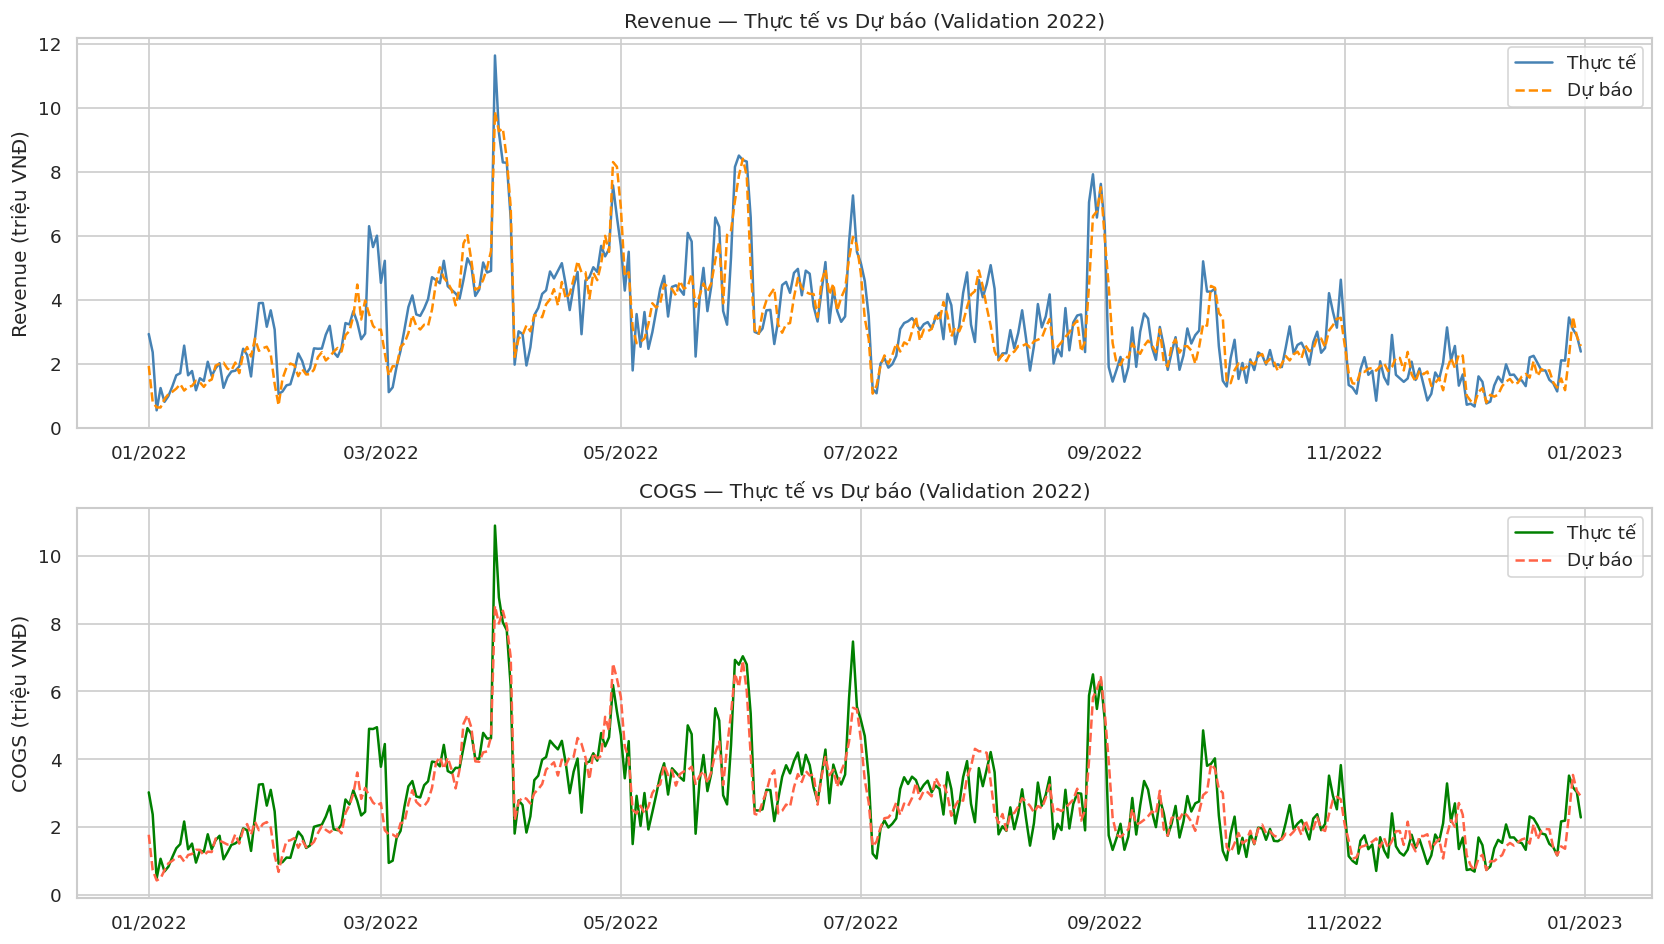

In [41]:
# Visualise Validation
val_dates = df.loc[vm, 'Date']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(val_dates, y_val_rev / 1e6, label='Thực tế', lw=1.5, color='steelblue')
axes[0].plot(val_dates, val_pred_rev / 1e6, label='Dự báo', lw=1.5, color='darkorange', ls='--')
axes[0].set_title('Revenue — Thực tế vs Dự báo (Validation 2022)')
axes[0].set_ylabel('Revenue (triệu VNĐ)'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

axes[1].plot(val_dates, y_val_cogs / 1e6, label='Thực tế', lw=1.5, color='green')
axes[1].plot(val_dates, val_pred_cogs / 1e6, label='Dự báo', lw=1.5, color='tomato', ls='--')
axes[1].set_title('COGS — Thực tế vs Dự báo (Validation 2022)')
axes[1].set_ylabel('COGS (triệu VNĐ)'); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

plt.tight_layout()
plt.savefig('fig10_validation.png', dpi=150, bbox_inches='tight')
plt.show()

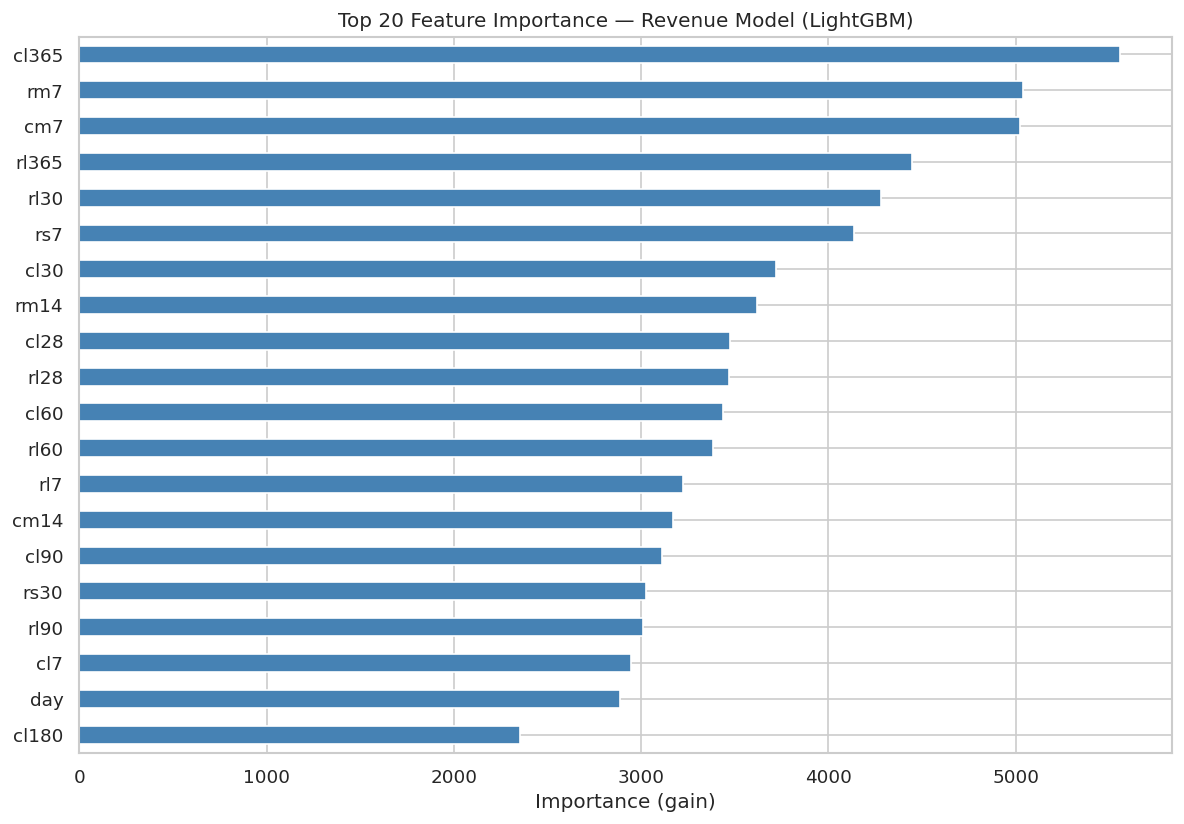

Top 10 features:
cl365    5558
rm7      5040
cm7      5020
rl365    4445
rl30     4280
rs7      4137
cl30     3720
rm14     3620
cl28     3472
rl28     3471


In [42]:
# Feature Importance
fi = pd.Series(model_rev.feature_importances_, index=FCOLS).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
fi.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importance — Revenue Model (LightGBM)')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig('fig11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(fi.head(10).to_string())

In [43]:
# Retrain toàn bộ và dự báo
print('Retraining on full data...')
model_rev.fit(df[FCOLS], df['Revenue'])
model_cogs.fit(df[FCOLS], df['COGS'])

# Khởi tạo lookup dict từ lịch sử
rev_lookup  = dict(zip(sales['Date'].values, sales['Revenue'].values.astype(float)))
cogs_lookup = dict(zip(sales['Date'].values, sales['COGS'].values.astype(float)))

def build_row_for_date(dt):
    """Tạo feature vector cho một ngày duy nhất dùng lookup dict."""
    dt_pd = pd.Timestamp(dt)
    doy, dow, yr = dt_pd.dayofyear, dt_pd.dayofweek, dt_pd.year
    row = {
        'month': dt_pd.month, 'dow': dow, 'year': yr, 'quarter': dt_pd.quarter,
        'day': dt_pd.day, 'woy': dt_pd.isocalendar()[1],
        'doy': doy, 'wknd': int(dow >= 5), 'yr_n': (yr - 2012) / 10.0,
    }
    for k in [1,2,3,4]:
        row[f'sy{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        row[f'cy{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    for k in [1,2]:
        row[f'sw{k}'] = np.sin(2 * np.pi * k * dow / 7)
        row[f'cw{k}'] = np.cos(2 * np.pi * k * dow / 7)
    for lag in LAGS:
        ld = (dt_pd - pd.Timedelta(days=lag)).to_datetime64()
        row[f'rl{lag}'] = rev_lookup.get(ld, np.nan)
        row[f'cl{lag}'] = cogs_lookup.get(ld, np.nan)
    for w in WINDOWS:
        vr = [rev_lookup.get((dt_pd - pd.Timedelta(days=d)).to_datetime64(), np.nan)
              for d in range(1, w+1)]
        vc = [cogs_lookup.get((dt_pd - pd.Timedelta(days=d)).to_datetime64(), np.nan)
              for d in range(1, w+1)]
        vr = [v for v in vr if not np.isnan(v)]
        vc = [v for v in vc if not np.isnan(v)]
        row[f'rm{w}'] = float(np.mean(vr)) if vr else np.nan
        row[f'rs{w}'] = float(np.std(vr))  if len(vr) > 1 else 0.0
        row[f'cm{w}'] = float(np.mean(vc)) if vc else np.nan
    return row

test_dates = pd.to_datetime(sub_sample['Date'].values)
pred_rev_list, pred_cogs_list = [], []

print(f'Running recursive prediction for {len(test_dates)} test days...')
for i, dt in enumerate(test_dates):
    row   = build_row_for_date(dt)
    Xrow  = pd.DataFrame([row])[FCOLS]
    pr    = float(model_rev.predict(Xrow)[0])
    pc    = float(model_cogs.predict(Xrow)[0])
    pred_rev_list.append(pr)
    pred_cogs_list.append(pc)
    rev_lookup[pd.Timestamp(dt).to_datetime64()]  = pr
    cogs_lookup[pd.Timestamp(dt).to_datetime64()] = pc
    if (i + 1) % 100 == 0:
        print(f'  [{i+1:3d}/{len(test_dates)}] {pd.Timestamp(dt).date()} '
              f'Revenue={pr:>10,.0f}  COGS={pc:>10,.0f}')

print('\nPrediction complete!')

Retraining on full data...
Running recursive prediction for 548 test days...
  [100/548] 2023-04-10 Revenue= 3,764,124  COGS= 3,588,534
  [200/548] 2023-07-19 Revenue= 3,402,041  COGS= 3,347,888
  [300/548] 2023-10-27 Revenue= 3,241,303  COGS= 2,630,320
  [400/548] 2024-02-04 Revenue= 1,754,327  COGS= 1,308,116
  [500/548] 2024-05-14 Revenue= 4,991,400  COGS= 3,849,241

Prediction complete!


In [44]:
# File submission
submission = pd.DataFrame({
    'Date'   : sub_sample['Date'].dt.strftime('%Y-%m-%d'),
    'Revenue': [round(v, 2) for v in pred_rev_list],
    'COGS'   : [round(v, 2) for v in pred_cogs_list],
})
submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved ({len(submission)} rows)')
print(submission.head(10).to_string(index=False))

submission.csv saved (548 rows)
      Date    Revenue       COGS
2023-01-01 2672662.60 2553636.56
2023-01-02 1812180.07 1500164.96
2023-01-03 1383827.75 1003648.90
2023-01-04 1039731.24  766913.81
2023-01-05  854872.37  653948.33
2023-01-06 1099783.28  784262.30
2023-01-07 1373827.36 1256829.03
2023-01-08 1911201.11 1690742.08
2023-01-09 1888191.81 1625700.54
2023-01-10 1782180.13 1525293.25


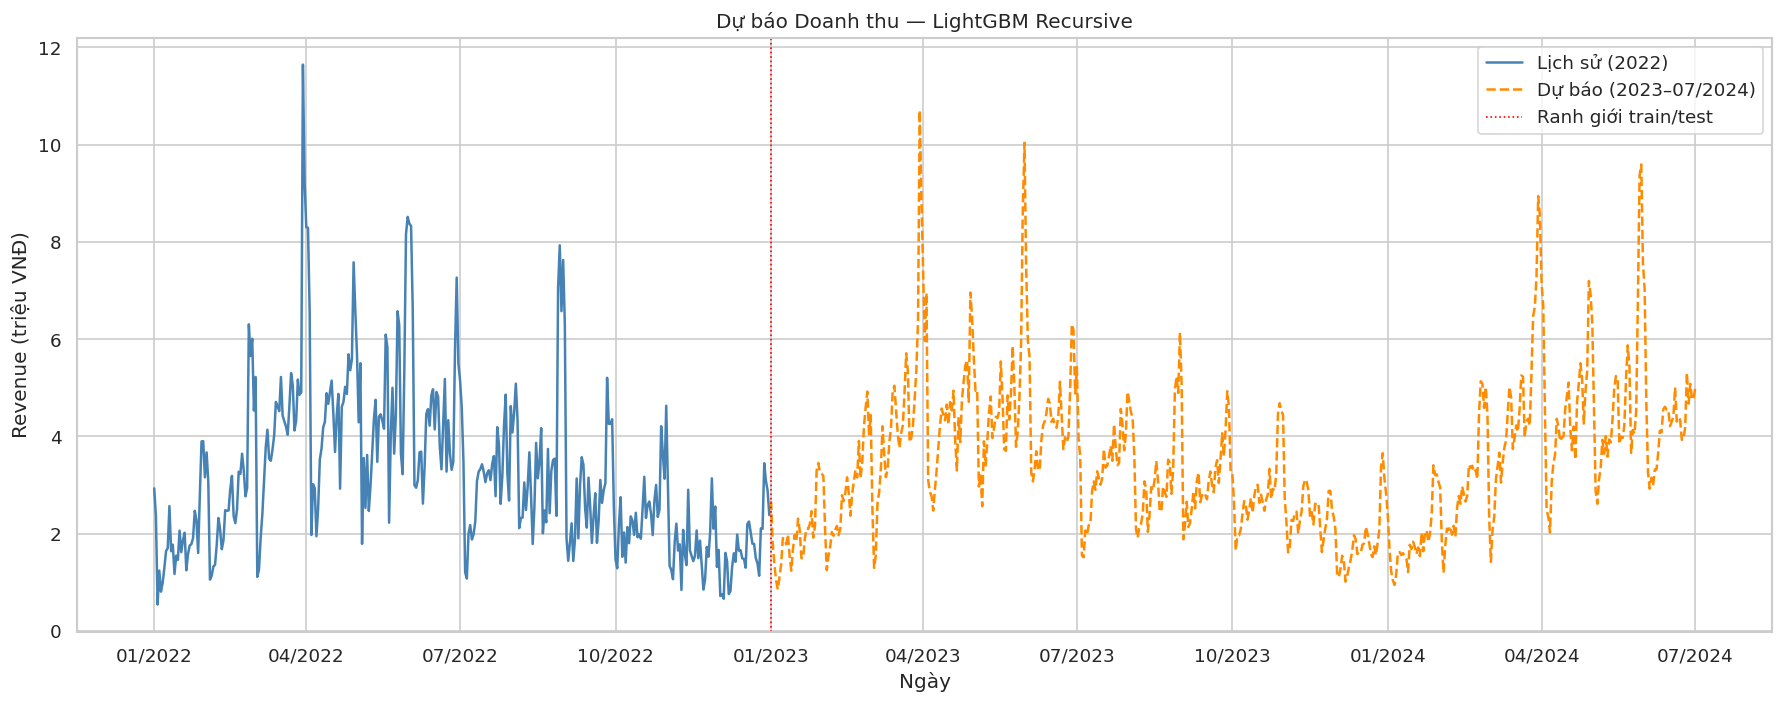


Revenue dự báo — mean: 3.49M | min: 0.85M | max: 10.70M


In [45]:
# Visualise dự báo
fig, ax = plt.subplots(figsize=(15, 6))

# Train history (last 365 days only for clarity)
recent_train = sales[sales['Date'] >= '2022-01-01']
ax.plot(recent_train['Date'], recent_train['Revenue'] / 1e6,
        label='Lịch sử (2022)', color='steelblue', lw=1.5)

# Forecast
sub_dates = pd.to_datetime(submission['Date'])
ax.plot(sub_dates, submission['Revenue'] / 1e6,
        label='Dự báo (2023–07/2024)', color='darkorange', lw=1.5, ls='--')

ax.axvline(pd.Timestamp('2023-01-01'), color='red', ls=':', lw=1, label='Ranh giới train/test')
ax.set_title('Dự báo Doanh thu — LightGBM Recursive')
ax.set_xlabel('Ngày'); ax.set_ylabel('Revenue (triệu VNĐ)')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.tight_layout()
plt.savefig('fig12_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nRevenue dự báo — mean: {np.mean(pred_rev_list)/1e6:.2f}M | '
      f'min: {np.min(pred_rev_list)/1e6:.2f}M | max: {np.max(pred_rev_list)/1e6:.2f}M')